In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
data = {
    "review": [
        "The movie was excellent and the acting was amazing",
        "I really enjoyed this movie and the story was wonderful",
        "Amazing film with great performances",
        "The story was interesting and entertaining",
        "Excellent direction and brilliant acting",
        "I loved every part of this movie",
        "The movie was fantastic and enjoyable",
        "Great movie with a beautiful story",
        "The actors performed very well",
        "A wonderful and memorable movie",

        "The movie was boring and disappointing",
        "I did not enjoy this movie at all",
        "The story was terrible and confusing",
        "Very boring movie with poor acting",
        "The film was disappointing and slow",
        "I hated this movie and wasted my time",
        "Bad story and terrible performances",
        "The movie was not interesting",
        "Poor direction and boring scenes",
        "Worst movie with a disappointing story"
    ],
    "sentiment": [
        "positive", "positive", "positive", "positive", "positive",
        "positive", "positive", "positive", "positive", "positive",
        "negative", "negative", "negative", "negative", "negative",
        "negative", "negative", "negative", "negative", "negative"
    ]
}

df = pd.DataFrame(data)

print(df)
print("\nDataset Shape:", df.shape)

                                               review sentiment
0   The movie was excellent and the acting was ama...  positive
1   I really enjoyed this movie and the story was ...  positive
2                Amazing film with great performances  positive
3          The story was interesting and entertaining  positive
4            Excellent direction and brilliant acting  positive
5                    I loved every part of this movie  positive
6               The movie was fantastic and enjoyable  positive
7                  Great movie with a beautiful story  positive
8                      The actors performed very well  positive
9                     A wonderful and memorable movie  positive
10             The movie was boring and disappointing  negative
11                  I did not enjoy this movie at all  negative
12               The story was terrible and confusing  negative
13                 Very boring movie with poor acting  negative
14                The film was disappoin

sentiment
positive    10
negative    10
Name: count, dtype: int64


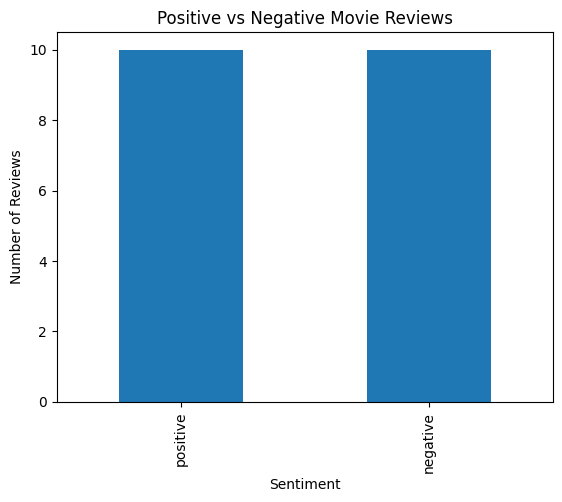

In [3]:
print(df["sentiment"].value_counts())

df["sentiment"].value_counts().plot(kind="bar")
plt.title("Positive vs Negative Movie Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [4]:
X = df["review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16
Testing samples: 4


In [5]:
vectorizer = TfidfVectorizer(stop_words="english")

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF conversion completed!")
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

TF-IDF conversion completed!
Training TF-IDF shape: (16, 32)
Testing TF-IDF shape: (4, 32)


In [6]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [7]:
y_pred = model.predict(X_test_tfidf)

print("Actual Sentiments:")
print(y_test.values)

print("\nPredicted Sentiments:")
print(y_pred)

Actual Sentiments:
['negative' 'negative' 'positive' 'positive']

Predicted Sentiments:
['negative' 'negative' 'positive' 'negative']


In [8]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 75.0 %


In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.67      1.00      0.80         2
    positive       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



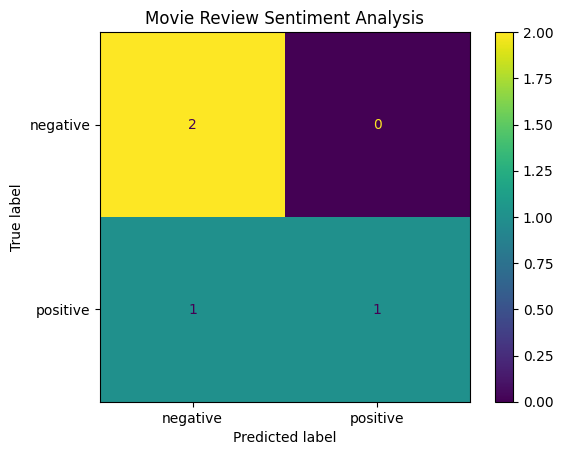

In [10]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Movie Review Sentiment Analysis")
plt.show()

In [11]:
review = ["The movie was amazing with excellent acting and a wonderful story"]

review_tfidf = vectorizer.transform(review)

prediction = model.predict(review_tfidf)

print("Review:", review[0])
print("Prediction:", prediction[0].upper())

Review: The movie was amazing with excellent acting and a wonderful story
Prediction: POSITIVE


In [12]:
review = ["The movie was boring and the story was terrible"]

review_tfidf = vectorizer.transform(review)

prediction = model.predict(review_tfidf)

print("Review:", review[0])
print("Prediction:", prediction[0].upper())

Review: The movie was boring and the story was terrible
Prediction: NEGATIVE
